## The cosine similarity based on Morgan Fingerprints

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### load precomputed Morgan Fingerprints

In [2]:
df = pd.read_parquet('molecular_descriptors_raw_models_.parquet')

In [3]:
df

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,ChyLine_l2-4_N#CC,ChyLine_l2-4_N#C,ChyLine_l2-4_N#CCC,ChyLine_l2-4_CSC,ChyLine_l2-4_CSCc,ChyLine_l2-4_SCS,ChyLine_l2-4_SCSC,ChyLine_l2-4_CCCc,ChyLine_l2-4_cCCc,ChyLine_l2-4_O=CCc
0,26.682927,5.770088,3.024390,6.178260,153.267812,105.649934,1.844467,5.906402,3.601607,7.350701,...,0,0,0,0,0,0,0,0,0,0
1,25.935484,5.706245,2.580645,4.751892,158.057747,102.435555,1.691055,5.821371,3.519689,7.342506,...,0,0,0,0,0,0,0,0,0,0
2,23.860465,5.661247,2.744186,4.914154,157.443307,94.120542,1.670321,5.779477,3.312805,7.283060,...,0,0,0,0,0,0,0,0,0,0
3,24.764706,5.671282,2.529412,4.450254,158.718230,97.699954,1.650025,5.783676,3.334128,7.311622,...,0,0,0,0,0,0,0,0,0,0
4,24.764706,5.671282,2.588235,4.567901,158.718230,97.699954,1.650025,5.783676,3.349651,7.311622,...,0,0,0,0,0,0,0,0,0,0
5,24.893617,5.711353,2.893617,5.559758,154.834886,98.388081,1.765519,5.841011,3.322679,7.304971,...,0,0,0,0,0,0,0,0,0,0
6,24.893617,5.711353,2.936170,5.644865,154.834886,98.388081,1.765519,5.841011,3.333908,7.304971,...,0,0,0,0,0,0,0,0,0,0
7,25.708333,5.847575,2.958333,6.277263,155.472727,101.670996,1.742137,5.965856,3.519660,7.430945,...,0,0,0,0,0,0,0,0,0,0
8,32.272727,5.810739,3.068182,6.020763,153.723903,130.309772,1.900206,5.988423,3.443285,7.448031,...,0,0,0,0,0,0,0,0,0,0
9,30.000000,6.475396,3.255319,9.091673,162.407416,121.361906,1.756942,6.543164,7.303323,7.897410,...,0,0,0,0,0,0,0,0,0,0


In [4]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Separate columns to standardize and those to keep as is
cols_to_standardize = [col for col in df.columns if "C_FP_" not in col]
cols_to_keep = [col for col in df.columns if "C_FP_" in col]


# Keep the other columns as is
df_unchanged = df[cols_to_keep]

# Remove columns that are entirely zeros
df_unchanged = df_unchanged.loc[:, (df_unchanged != 0).any(axis=0)]

# Ensure original column order
df_final = df_unchanged

# Compute cosine similarity matrix between rows
similarity_matrix = cosine_similarity(df_final.values)

# Convert similarity matrix back to DataFrame for easier interpretation (optional)
similarity_df = pd.DataFrame(similarity_matrix, index=df_final.index, columns=df_final.index)
print(similarity_df)

# Calculate overall average similarity excluding self-similarity
np.fill_diagonal(similarity_matrix, np.nan)
overall_similarity = np.nanmean(similarity_matrix)
print(f"Overall average similarity in dataset: {overall_similarity:.4f}")

          0         1         2         3         4         5         6   \
0   1.000000  0.786852  0.937599  0.748616  0.744633  0.974637  0.936193   
1   0.786852  1.000000  0.731932  0.978589  0.903083  0.816964  0.815317   
2   0.937599  0.731932  1.000000  0.696364  0.712969  0.928977  0.901351   
3   0.748616  0.978589  0.696364  1.000000  0.896153  0.777264  0.775697   
4   0.744633  0.903083  0.712969  0.896153  1.000000  0.775865  0.790253   
5   0.974637  0.816964  0.928977  0.777264  0.775865  1.000000  0.947320   
6   0.936193  0.815317  0.901351  0.775697  0.790253  0.947320  1.000000   
7   0.932480  0.812084  0.897777  0.772621  0.787119  0.943563  0.977491   
8   0.936193  0.815317  0.890991  0.775697  0.779990  0.947320  0.978723   
9   0.913399  0.795466  0.872667  0.756811  0.760999  0.924255  0.954894   
10  0.953959  0.829986  0.900310  0.789653  0.794973  0.961624  0.959167   
11  0.951815  0.828177  0.900511  0.787932  0.792453  0.959717  0.967312   
12  0.933440

In [5]:
df_final

,C_FP_1,C_FP_2,C_FP_4,C_FP_14,C_FP_25,C_FP_31,C_FP_32,C_FP_33,C_FP_39,C_FP_45,...,C_FP_1976,C_FP_1979,C_FP_1985,C_FP_1991,C_FP_1996,C_FP_1999,C_FP_2023,C_FP_2029,C_FP_2033,C_FP_2041
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [6]:
# Find minimal similarity value (excluding diagonal)
min_similarity = np.nanmin(similarity_matrix)

print(f"Minimal similarity between any two rows: {min_similarity:.4f}")
# Find maximal similarity value (excluding diagonal)
min_similarity = np.nanmax(similarity_matrix)

print(f"Maximal similarity between any two rows: {min_similarity:.4f}")

Minimal similarity between any two rows: 0.6210
Maximal similarity between any two rows: 0.9897


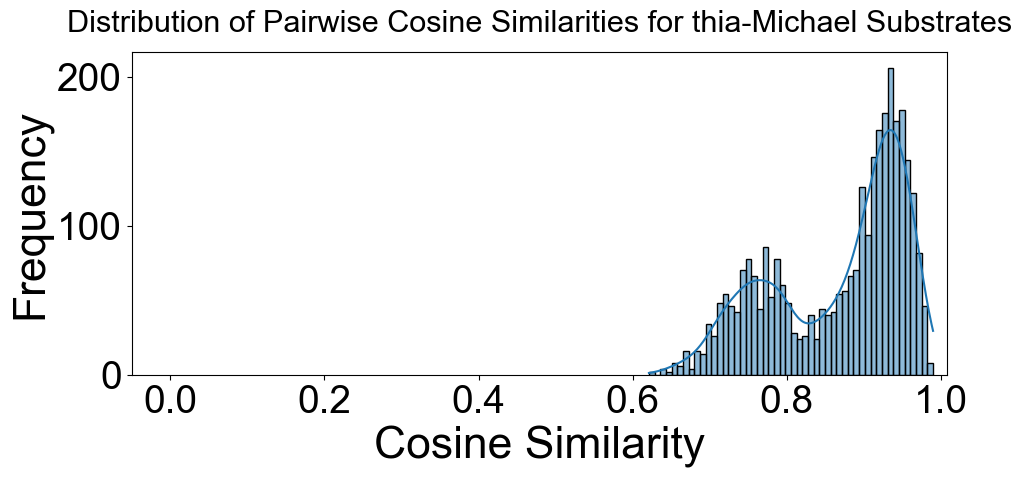

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Set a clean font for better readability
plt.rcParams['font.family'] = 'Arial'  # Or 'Helvetica', 'sans-serif', etc.

# Create figure with specified size
plt.figure(figsize=(10, 5))

# Plot the distribution using seaborn
sns.histplot(sim_values, bins=50, kde=True)

# Customize font sizes for better visibility
plt.title('Distribution of Pairwise Cosine Similarities for thia-Michael Substrates', fontsize=22, pad=15)
plt.xlabel('Cosine Similarity', fontsize=32)
plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.xlim(-0.05)
plt.ylabel('Frequency', fontsize=32)
plt.tick_params(axis='both', which='major', labelsize=28)  # Larger tick labels

# Adjust layout to prevent clipping
plt.tight_layout(pad=1.5)  # Add padding to avoid text cutoff

# Save to file with high DPI and tight bounding box
plt.savefig('cosine_similarities_II.svg', bbox_inches='tight', format='svg', dpi=300)

# Show the plot (optional, comment out if only saving)
plt.show()

# Close figure to free memory
plt.close()